# 04 - Power Plant Design
**Team:** Artemis  
**Project:** SPE Africa Energython 2026 - Molecule to Megabyte

This notebook focuses on the technical architecture of the 15 MW natural gas-fired power plant, evaluating engine selection, redundancy configuration (N+1), and electrical parameters.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Selected Engine: INNIO Jenbacher J624
engine_data = {
    'Parameter': [
        'Model',
        'Cylinders',
        'Speed (RPM)',
        'Electrical Output (kW)',
        'Electrical Efficiency (%)',
        'Thermal Output (kW)',
        'Thermal Efficiency (%)',
        'Total Efficiency (%)'
    ],
    'Value': [
        'J624 GS',
        24,
        1500,
        4450,
        46.8,
        4180,
        43.9,
        90.7
    ]
}
df_engine = pd.DataFrame(engine_data)
df_engine


,Parameter,Value
0,Model,J624 GS
1,Cylinders,24
2,Speed (RPM),1500
3,Electrical Output (kW),4450
4,Electrical Efficiency (%),46.8
5,Thermal Output (kW),4180
6,Thermal Efficiency (%),43.9
7,Total Efficiency (%),90.7


## 04.1 N+1 Redundancy Configuration

An N+1 configuration means we have N units needed to meet the peak load, plus 1 redundant unit.
For a 15 MW IT load + 2.8 MW facility overhead (total ~17.8 MW gross load), we need 4 engines running.


In [2]:
engine_capacity_mw = 4.45
target_gross_load_mw = 17.8

n_engines_required = np.ceil(target_gross_load_mw / engine_capacity_mw)
total_engines_n1 = n_engines_required + 1

print(f"Target Gross Load: {target_gross_load_mw} MW")
print(f"N (Engines Required): {n_engines_required}")
print(f"Total Engines Installed (N+1): {total_engines_n1}")
print(f"Total Installed Capacity: {total_engines_n1 * engine_capacity_mw} MW")


Target Gross Load: 17.8 MW
N (Engines Required): 4.0
Total Engines Installed (N+1): 5.0
Total Installed Capacity: 22.25 MW


## 04.2 Load Step & Ramp Analysis

Data centers require strict frequency and voltage stability. Gas engines must be capable of accepting block loads without violating ISO 8528-5 G3 standards. 
The J624 handles load steps via advanced engine management (LEANOX).


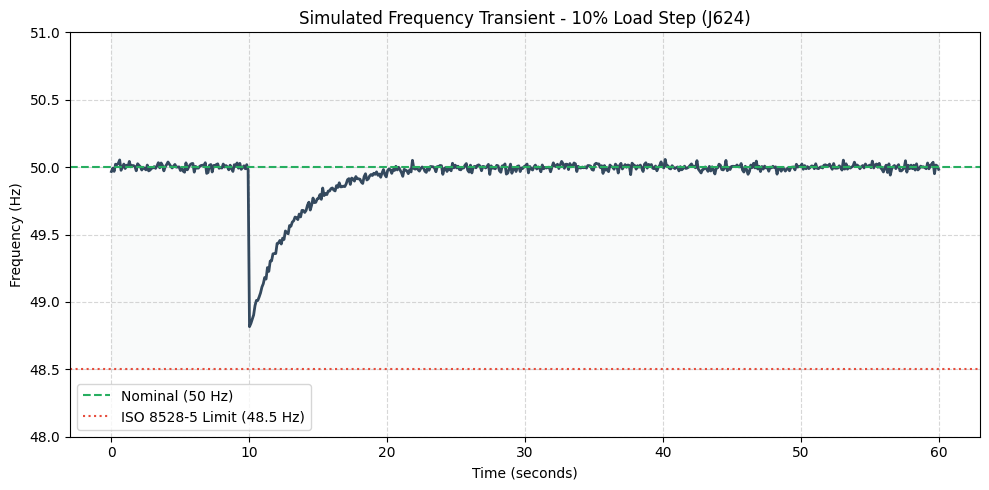

In [3]:
time_sec = np.linspace(0, 60, 600)
# Simulated frequency drop during a 10% load step at t=10s
frequency = np.ones_like(time_sec) * 50.0

load_step_idx = 100 # 10 seconds
recovery_tau = 3.0 # 3 seconds recovery

frequency[load_step_idx:] = 50.0 - 1.2 * np.exp(-(time_sec[load_step_idx:] - 10) / recovery_tau)
frequency += np.random.normal(0, 0.02, len(time_sec))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_sec, frequency, color='#34495e', linewidth=2)
ax.axhline(50.0, color='#27ae60', linestyle='--', label='Nominal (50 Hz)')
ax.axhline(48.5, color='#e74c3c', linestyle=':', label='ISO 8528-5 Limit (48.5 Hz)')
ax.fill_between(time_sec, 48.5, 51.5, color='#ecf0f1', alpha=0.3)

ax.set_title('Simulated Frequency Transient - 10% Load Step (J624)')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Frequency (Hz)')
ax.set_ylim(48.0, 51.0)
ax.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../outputs/figures/04_transient_response.png', dpi=300)
plt.show()
